# Explore ultrasound region growing

Use this notebook to interactively inspect preprocessing and single-seed region growing masks on your ultrasound frames.

Make sure you select the `ultrasound3d` conda environment as the kernel.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.segmentation import flood, active_contour
from skimage.filters import gaussian, sobel
from skimage.draw import polygon
from skimage.morphology import opening, closing, dilation, disk, footprint_rectangle
from skimage.exposure import equalize_adapthist
from skimage.measure import find_contours

%matplotlib inline

# Parameters copied from the CLI script
CLAHE_CLIP_LIMIT = 0.01
GAUSSIAN_KERNEL = (7, 7)
CROP_Y_MIN, CROP_Y_MAX = 100, 700
CROP_X_MIN, CROP_X_MAX = 200, 800

# Cleaning / snake parameters (same defaults as script)
CLEAN_Y_BAND = 35
CLEAN_MIN_AREA = 200
OPEN_DISK_RADIUS = 1
CLOSE_RECT_WIDTH = 25
SNAKE_DILATE_RADIUS = 3


def load_image(path: str) -> np.ndarray:
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(path)
    return img


def crop_ultrasound_region(img: np.ndarray) -> np.ndarray:
    return img[CROP_Y_MIN:CROP_Y_MAX, CROP_X_MIN:CROP_X_MAX]


def preprocess_image(img: np.ndarray) -> np.ndarray:
    img_norm = img / 255.0
    clahe = equalize_adapthist(img_norm, clip_limit=CLAHE_CLIP_LIMIT)
    clahe_8bit = (clahe * 255).astype(np.uint8)
    blurred = cv2.GaussianBlur(clahe_8bit, GAUSSIAN_KERNEL, 0)
    return blurred


def region_growing(img: np.ndarray, seed, tolerance: int):
    """Wrapper around skimage.segmentation.flood."""
    return flood(img, seed_point=seed, tolerance=tolerance)


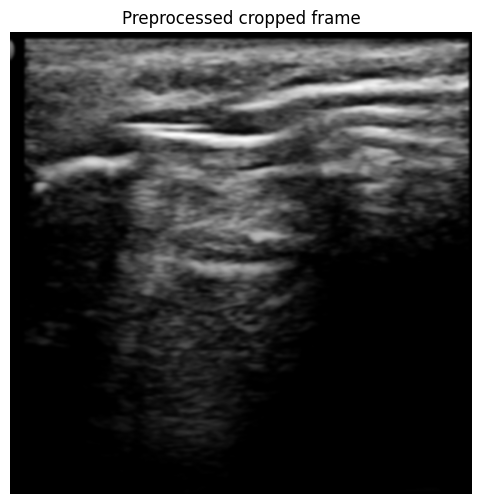

In [2]:
# Load and preprocess a specific frame

image_path = "Dataset/Patient1/IMG_frames/image_283536217682_f000.png"  # change to any frame you like

img_full = load_image(image_path)
img_crop = crop_ultrasound_region(img_full)
pre = preprocess_image(img_crop)

plt.figure(figsize=(6, 6))
plt.imshow(pre, cmap="gray")
plt.title("Preprocessed cropped frame")
plt.axis("off")
plt.show()

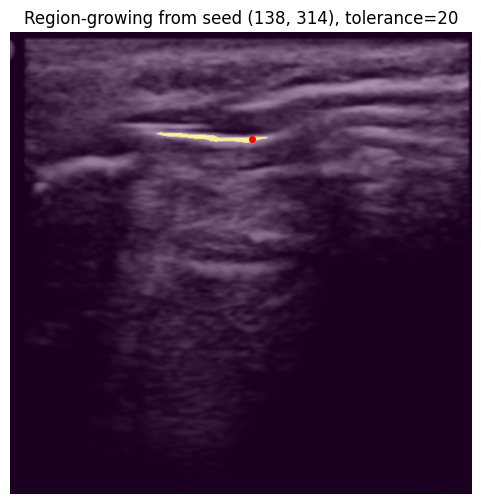

In [11]:
# Experiment with a single seed and tolerance

# Example seed (row, col) in the cropped image coordinate system
seed = (138, 314)   # adjust after inspecting the image above
tolerance = 20      # same meaning as --tolerance in the CLI

mask = region_growing(pre, seed, tolerance)

plt.figure(figsize=(6, 6))
plt.imshow(pre, cmap="gray")
plt.imshow(mask, alpha=0.4)

# mark the seed point on top of the overlay
plt.plot(seed[1], seed[0], "ro", markersize=4)

plt.title(f"Region-growing from seed {seed}, tolerance={tolerance}")
plt.axis("off")
plt.show()

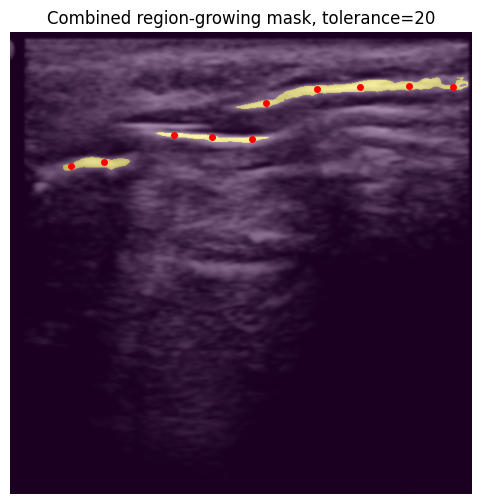

In [3]:
# Combine multiple seeds and visualize combined region-growing mask

# Define seeds in cropped coordinates (row, col)
# Start with a couple of points on the bone; tweak as needed
seeds = [(71, 575), (69, 518), (71, 454), (73, 398), (92, 332), (138, 314), (136, 262), (133, 213), (173, 79), (168, 122)]

combined_tolerance = 20  # same as --tolerance in the CLI

combined_mask = np.zeros_like(pre, dtype=bool)
for s in seeds:
    m = region_growing(pre, s, combined_tolerance)
    combined_mask |= m

plt.figure(figsize=(6, 6))
plt.imshow(pre, cmap="gray")
plt.imshow(combined_mask, alpha=0.4)

for s in seeds:
    plt.plot(s[1], s[0], "ro", markersize=4)

plt.title(f"Combined region-growing mask, tolerance={combined_tolerance}")
plt.axis("off")
plt.show()


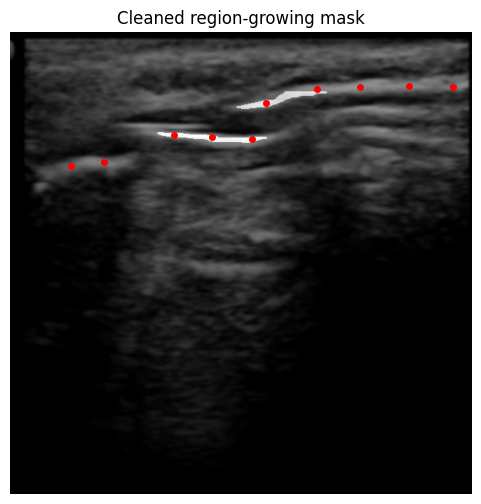

In [16]:
# Clean the combined mask using the same logic as the CLI script

def clean_mask(mask, seeds, y_band=CLEAN_Y_BAND, min_area=CLEAN_MIN_AREA,
               open_r=OPEN_DISK_RADIUS, close_w=CLOSE_RECT_WIDTH):
    """Clean the combined region-growing mask in a seed-robust way."""
    mask_bin = (mask > 0).astype(np.uint8)

    h, w = mask_bin.shape
    mean_y = int(np.mean([s[0] for s in seeds])) if len(seeds) > 0 else h // 2

    y_min = max(0, mean_y - y_band)
    y_max = min(h, mean_y + y_band)

    band = np.zeros_like(mask_bin, dtype=bool)
    band[y_min:y_max, :] = True
    mask_band = (mask_bin.astype(bool) & band).astype(np.uint8)

    opened = opening(mask_band, disk(open_r)).astype(np.uint8)

    # bridge gaps along x
    closed = closing(opened, footprint_rectangle((1, close_w))).astype(np.uint8)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(closed, connectivity=8)
    if num_labels <= 1:
        return np.zeros_like(mask_bin, dtype=np.uint8)

    # collect CC labels under seed points
    seed_labels = set()
    for (r, c) in seeds:
        if 0 <= r < h and 0 <= c < w:
            lbl = labels[r, c]
            if lbl != 0:
                seed_labels.add(lbl)

    if not seed_labels:
        return np.zeros_like(mask_bin, dtype=np.uint8)

    keep = np.zeros_like(mask_bin, dtype=bool)
    for lbl in seed_labels:
        area = stats[lbl, cv2.CC_STAT_AREA]
        if area >= min_area:
            keep |= (labels == lbl)

    return (keep.astype(np.uint8) * 255)


mask_clean = clean_mask(combined_mask, seeds)

plt.figure(figsize=(6, 6))
plt.imshow(pre, cmap="gray")
plt.imshow(mask_clean, alpha=0.4, cmap="gray")

for s in seeds:
    plt.plot(s[1], s[0], "ro", markersize=4)

plt.title("Cleaned region-growing mask")
plt.axis("off")
plt.show()


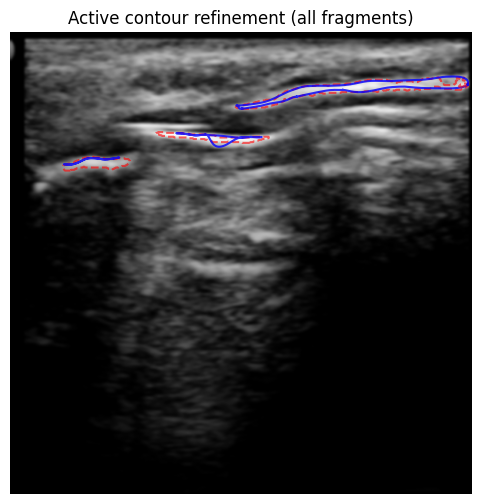

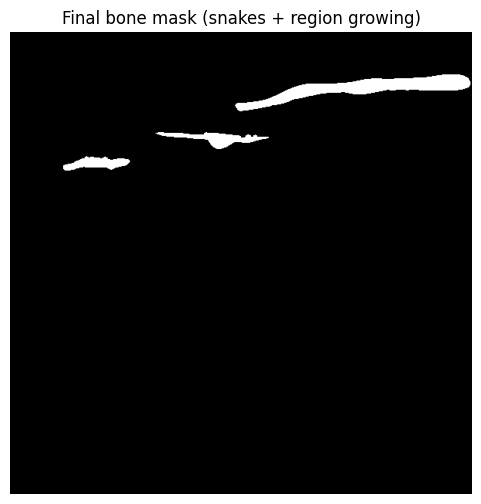

In [7]:
# Active contour refinement on all fragments + final mask construction
mask_clean = (combined_mask.astype(np.uint8) * 255)

def active_contour_refinement_from_mask(img, mask):
    """Refine all mask contours with an edge-based snake."""
    smoothed = gaussian(img, sigma=1.0)
    contours = find_contours(mask.astype(float), level=0.5)
    if not contours:
        raise ValueError("No contour found in the mask.")

    edges = sobel(smoothed)

    init_list = []
    snake_list = []

    for init in contours:
        if len(init) < 5:
            continue

        snake = active_contour(
            edges,
            init,
            alpha=0.0015,  # internal tension
            beta=0.3,      # smoothness
            gamma=0.01,    # time step
            w_line=0.0,
            w_edge=1.0,
        )

        init_list.append(init)
        snake_list.append(snake)

    if not snake_list:
        raise ValueError("No valid contours for active contour refinement.")

    return init_list, snake_list


def create_mask_from_contour(img_shape, contour) -> np.ndarray:
    mask = np.zeros(img_shape, dtype=np.uint8)
    rr, cc = polygon(contour[:, 0], contour[:, 1], img_shape)
    mask[rr, cc] = 255
    return mask


init_list, snake_list = active_contour_refinement_from_mask(pre, combined_mask) #mask_clean)

plt.figure(figsize=(6, 6))
plt.imshow(pre, cmap="gray")
for init, snake in zip(init_list, snake_list):
    plt.plot(init[:, 1], init[:, 0], "--r", alpha=0.6)
    plt.plot(snake[:, 1], snake[:, 0], "-b", alpha=0.8)
plt.title("Active contour refinement (all fragments)")
plt.axis("off")
plt.show()

# Build final mask from all snakes and cleaned region-growing prior
snake_mask = np.zeros_like(pre, dtype=np.uint8)
for snake in snake_list:
    snake_mask |= create_mask_from_contour(pre.shape, snake)

clean_bin = (mask_clean > 0).astype(np.uint8)
snake_bin = (snake_mask > 0).astype(np.uint8)

snake_thick = dilation(snake_bin, disk(SNAKE_DILATE_RADIUS)).astype(np.uint8)
final_bin = ((snake_thick | clean_bin).astype(np.uint8))
final_mask = final_bin * 255

plt.figure(figsize=(6, 6))
plt.imshow(final_mask, cmap="gray")
plt.title("Final bone mask (snakes + region growing)")
plt.axis("off")
plt.show()


In [5]:
print(mask.size)

360000
